In [1]:
# Import necessary libraries
import os
import gc
import cv2
import ast
import math
import shutil
import numpy as np
import pandas as pd 
import albumentations as A
from PIL import Image
import SimpleITK as sitk
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.metrics import precision_score, recall_score, roc_auc_score,classification_report,confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from transformers import AutoFeatureExtractor, TFAutoModel
import warnings
warnings.filterwarnings('ignore')

/usr/local/lib/python3.10/dist-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.20). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [2]:
# Read the metadata file
metadata = pd.read_csv('/kaggle/input/prostate-cancer-pi-cai-dataset/Metadata with lesion info.csv')

In [3]:
metadata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 871 entries, 0 to 870
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          871 non-null    int64  
 1   patient_id          871 non-null    int64  
 2   study_id            871 non-null    int64  
 3   psa                 871 non-null    float64
 4   psad                871 non-null    float64
 5   prostate_volume     871 non-null    float64
 6   num_lesions         871 non-null    int64  
 7   max_prim_score      871 non-null    int64  
 8   max_sec_score       871 non-null    int64  
 9   max_gleason_scores  871 non-null    int64  
 10  case_ISUP           871 non-null    int64  
 11  case_csPCa          871 non-null    int64  
dtypes: float64(3), int64(9)
memory usage: 81.8 KB


In [4]:
metadata.head()

,Unnamed: 0,patient_id,study_id,psa,psad,prostate_volume,num_lesions,max_prim_score,max_sec_score,max_gleason_scores,case_ISUP,case_csPCa
0,0,10000,1000000,0.032648,0.018868,0.230769,1,0,0,0,0,0
1,1,10003,1000003,0.056351,0.024673,0.305430,1,0,0,0,0,0
2,2,10004,1000004,0.033989,0.013062,0.334842,2,0,0,0,0,0
3,3,10005,1000005,0.052326,0.033382,0.212670,2,4,3,7,3,1
4,4,10006,1000006,0.025939,0.031930,0.104072,2,3,3,6,1,0


In [5]:
metadata.drop(columns = ['Unnamed: 0'],inplace = True)

In [6]:
# Create patientID_caseID for each record in the metadata

patientID = list(metadata['patient_id'])
caseID = list(metadata['study_id'])

patientID = [str(i) for i in patientID]
caseID = [str(i) for i in caseID]

pcID = []
for i,j in zip(patientID,caseID):
    pcID.append(i+'_'+j)
#metadata['patient_caseID'] = pcID

### Helper functions:
1) To display a slice of the MRI<br>
2) Select the no. of slices to consider from the MRI<br>
3) Resize to specific (height,width) using zero padding (or) bicublic interpolation

In [7]:
def display_img(img,title):
    '''Displays the middle slice of the MRI with it's size'''
    img_arr = sitk.GetArrayFromImage(img)
    plt.imshow(img_arr[img_arr.shape[0]//2],cmap = 'gray') # Middle slice of the image
    plt.axis('off')
    plt.title(f'{title}: {img_arr.shape[1:]}')
    plt.show()

In [8]:
def select_slice(img,num_slices):
    '''Takes the specified number of slices from the middle portion of the original image''' 
    size = img.GetSize()
    depth = size[2]
    start_slice = (depth - num_slices)//2
    end_slice = start_slice + num_slices
    return sitk.RegionOfInterest(img,[size[0],size[1],num_slices],[0,0,start_slice])
   

In [9]:
def zero_pad(img,trg_height,trg_width):
    '''Pads the given image to required height & width'''

    # Convert the sitk object into a numpy array
    img_arr = sitk.GetArrayFromImage(img)
    
    # Calculate the remaining area to be padded
    pad_height = (trg_height - img_arr.shape[1])//2 # Gives the size for padding top & bottom
    pad_width = (trg_width - img_arr.shape[2])//2 # Gives the size for padding left & right

    # Ensure padding is done equally on all sides
    pad_3d = ((0,0),(pad_height,pad_height),(pad_width,pad_width))

    # Applying zero padding across all sides
    padded_img = np.pad(img_arr,pad_3d,mode = 'constant',constant_values = 0)

    return sitk.GetImageFromArray(padded_img)

In [10]:
def interpolate(img,trg_height,trg_width):
    '''Performs bicubic interpolation slice by slice'''
    img_arr = sitk.GetArrayFromImage(img)

    # Contains the newly resized slices
    resized_slices = []

    for i in range(img_arr.shape[0]):
        # Resize each slice using bicubic interpolation
        resized_slices.append(cv2.resize(img_arr[i],(trg_height,trg_width),interpolation = cv2.INTER_CUBIC))

    # Stack the resized slices
    resized_arr = np.stack(resized_slices, axis = 0)
    
    # Return normalized image
    return sitk.GetImageFromArray(resized_arr)

### Move the necessary files to output directory
Each folder is named after the patientID, each consists of 5 MRI modalities.<br>
We consider only the patients whose details exist in the preprocessed metadata file.<br>
We rename the folders as patient_caseID where each folder will contain only 3 MRI modalities(ADC, HBV, T2W) since a patient can have more than 1 case

In [11]:
# Defining the root directory
root_dir = '/kaggle/input/prostate-cancer-pi-cai-dataset'

# Creating an output directory
output_dir = '/kaggle/working/output_directory'
os.makedirs(output_dir, exist_ok=True)

In [12]:
# To ensure no. of records in the metadata match no. of cases in the output directory
num_cases = 0

# Iterate through the 5 main folders under the root directory
for main_folder in os.listdir(root_dir):
    main_folder_path = os.path.join(root_dir, main_folder)
    
    if os.path.isdir(main_folder_path):
        # Iterate through patient subfolders in each of the 5 main folders
        for patient_folder in os.listdir(main_folder_path):
            patient_folder_path = os.path.join(main_folder_path, patient_folder)
            
            if os.path.isdir(patient_folder_path):
                # Iterate through files in the patient folder
                for file_name in os.listdir(patient_folder_path):
                    # Extract patientID_caseID from the filename
                    patient_case_id = str(file_name.split('_')[0]+'_'+file_name.split('_')[1]) 
                    
                    if patient_case_id in pcID:
                            # Create a corresponding folder for each case in the output directory
                            output_subdir = os.path.join(output_dir, patient_case_id)
                            if not os.path.exists(output_subdir):  # Check if the folder exists
                                os.makedirs(output_subdir, exist_ok=True)
                                num_cases += 1
                                
                            # Exclude files ending with '_sag.mha' or '_cor.mha'
                            if not (file_name.endswith('_sag.mha') or file_name.endswith('_cor.mha')):
                                file_path = os.path.join(patient_folder_path, file_name)
                                shutil.copy(file_path, output_subdir)

print("Total cases:",num_cases)

Total cases: 871


### Resizing MRIs
We consider only the middle 16 slices of the MRIs.<br>
All MRI files are resized to (16,224,224) by performing bicubic interpolation.

In [13]:
for case_folder in os.listdir(output_dir):
    case_folder_path = os.path.join(output_dir, case_folder)
    
    if os.path.isdir(case_folder_path): 
        for file_name in os.listdir(case_folder_path):
            file_path = os.path.join(case_folder_path, file_name)
            img = sitk.ReadImage(file_path)
            resized_img = interpolate(select_slice(img,16),224,224)  
            sitk.WriteImage(resized_img, file_path)  # Overwriting the original file

In [14]:
# Create a unique identifier for each case
metadata['PatientID_CaseID'] = metadata['patient_id'].astype(str) + "_" + metadata['study_id'].astype(str)

In [15]:
metadata.head()

,patient_id,study_id,psa,psad,prostate_volume,num_lesions,max_prim_score,max_sec_score,max_gleason_scores,case_ISUP,case_csPCa,PatientID_CaseID
0,10000,1000000,0.032648,0.018868,0.230769,1,0,0,0,0,0,10000_1000000
1,10003,1000003,0.056351,0.024673,0.305430,1,0,0,0,0,0,10003_1000003
2,10004,1000004,0.033989,0.013062,0.334842,2,0,0,0,0,0,10004_1000004
3,10005,1000005,0.052326,0.033382,0.212670,2,4,3,7,3,1,10005_1000005
4,10006,1000006,0.025939,0.031930,0.104072,2,3,3,6,1,0,10006_1000006


In [16]:
 # No of augmented images to generate based on grade
aug_grades = {3: 1, 4: 5, 5: 3} 


medical_aug = A.Compose([
    A.RandomBrightnessContrast(p=0.2),
    A.GaussianBlur(blur_limit=(3,5), p=0.2),
    A.ElasticTransform(alpha=1, sigma=50, p=0.2),
    A.RandomGamma(gamma_limit=(80, 120), p=0.2),
])


def apply_augmentations(image_slice):
    image_slice = np.clip(image_slice, 0, None)  # Clip negative values
    augmented = medical_aug(image=image_slice)['image']
    return augmented

# Iterate through metadata
for idx, row in metadata.iterrows():
    grade = row['case_ISUP']
    if grade not in aug_grades:
        continue
        
    case_id = row['PatientID_CaseID']
    case_folder = os.path.join(output_dir, case_id)
    
    if os.path.exists(case_folder):
        original_output_folder = os.path.join(output_dir, case_id)
        os.makedirs(original_output_folder, exist_ok=True)
        
        original_images = {}  # Store original images

        for modality in ['t2w', 'adc', 'hbv']:
            original_file = os.path.join(case_folder, f"{case_id}_{modality}.mha")
            if os.path.exists(original_file):
                output_file = os.path.join(original_output_folder, f"{case_id}_{modality}.mha")
                original_images[modality] = sitk.ReadImage(original_file)
                sitk.WriteImage(original_images[modality], output_file)
                
                # Get image array and process each slice separately
                image_array = sitk.GetArrayFromImage(original_images[modality])  # Shape: (D, H, W)
                D, H, W = image_array.shape  

                for i in range(aug_grades[grade]):
                    aug_folder = os.path.join(output_dir, f"{case_id}_aug_{i+1:03d}")
                    os.makedirs(aug_folder, exist_ok=True)
                    
                    augmented_slices = []
                    
                    for d in range(D):  # Process each slice individually
                        slice_2d = image_array[d]  # Shape: (H, W)
                        augmented_slice = apply_augmentations(slice_2d) 
                        augmented_slices.append(augmented_slice)

                    # Convert back to 3D image
                    aug_sitk = sitk.GetImageFromArray(np.array(augmented_slices))  # Shape: (D, H, W)
                    aug_sitk.CopyInformation(original_images[modality])
                    
                    aug_file = os.path.join(aug_folder, f"{case_id}_aug_{i+1:03d}_{modality}.mha")
                    sitk.WriteImage(aug_sitk, aug_file)

In [17]:
# Initialize a list to store mapping information
image_data = []

# Iterate through patient folders, including augmented ones
for patient_case in os.listdir(output_dir):
    patient_dir = os.path.join(output_dir, patient_case)
    
    # Skip if not a directory
    if not os.path.isdir(patient_dir):
        continue
    
    # Extract the original case ID (handles both original & augmented cases)
    base_case_id = patient_case.split('_aug_')[0]  # Extract original case ID
    
    # Check if base case ID exists in the metadata
    if base_case_id in metadata['PatientID_CaseID'].values:
        # Fetch metadata for this patient
        case_data = metadata.loc[metadata['PatientID_CaseID'] == base_case_id].iloc[0]
        
        # Iterate through files in the case folder
        for file_name in os.listdir(patient_dir):
            file_path = os.path.join(patient_dir, file_name)
            
            if file_name.endswith('.mha'):
                # Extract modality (adc, hbv, t2w)
                modality = file_name.split('_')[-1].split('.')[0]
                
                # Determine if it's an augmented image
                is_augmented = "_aug_" in patient_case  # Check if it's augmented
                aug_suffix = ""
                
                if is_augmented:
                    # Assign a unique augmented name (10005_100005_a1, a2, etc.)
                    aug_id = patient_case.split('_aug_')[-1]  # Extract augmentation number
                    patient_case_name = f"{base_case_id}_a{int(aug_id):02d}"
                else:
                    patient_case_name = base_case_id  # Keep original ID for non-augmented data

                # Append mapping information
                image_data.append({
                    'ImagePath': file_path,
                    'PatientID_CaseID': patient_case_name,  # Modified for augmented cases
                    'Augmented': is_augmented,  # True if it's an augmented image
                    'Modality': modality,
                    'psa': case_data['psa'],
                    'psad': case_data['psad'],
                    'prostate_volume': case_data['prostate_volume'],
                    'num_lesions': case_data['num_lesions'],
                    'max_prim_score': case_data['max_prim_score'],
                    'max_sec_score': case_data['max_sec_score'],
                    'max_gleason_scores': case_data['max_gleason_scores'],
                    'case_ISUP': case_data['case_ISUP'],
                    'case_csPCa': case_data['case_csPCa']
                })

# Convert list to DataFrame
image_df = pd.DataFrame(image_data)
image_df.head(10)



,ImagePath,PatientID_CaseID,Augmented,Modality,psa,psad,prostate_volume,num_lesions,max_prim_score,max_sec_score,max_gleason_scores,case_ISUP,case_csPCa
0,/kaggle/working/output_directory/11115_1001138...,11115_1001138_a01,True,hbv,0.351521,0.288824,0.158371,1,4,5,9,5,1
1,/kaggle/working/output_directory/11115_1001138...,11115_1001138_a01,True,adc,0.351521,0.288824,0.158371,1,4,5,9,5,1
2,/kaggle/working/output_directory/11115_1001138...,11115_1001138_a01,True,t2w,0.351521,0.288824,0.158371,1,4,5,9,5,1
3,/kaggle/working/output_directory/10867_1000883...,10867_1000883,False,adc,0.047406,0.015965,0.384615,1,3,4,7,2,1
4,/kaggle/working/output_directory/10867_1000883...,10867_1000883,False,hbv,0.047406,0.015965,0.384615,1,3,4,7,2,1
5,/kaggle/working/output_directory/10867_1000883...,10867_1000883,False,t2w,0.047406,0.015965,0.384615,1,3,4,7,2,1
6,/kaggle/working/output_directory/11457_1001481...,11457_1001481,False,t2w,0.051878,0.029028,0.235294,1,3,3,6,1,0
7,/kaggle/working/output_directory/11457_1001481...,11457_1001481,False,adc,0.051878,0.029028,0.235294,1,3,3,6,1,0
8,/kaggle/working/output_directory/11457_1001481...,11457_1001481,False,hbv,0.051878,0.029028,0.235294,1,3,3,6,1,0
9,/kaggle/working/output_directory/11468_1001492...,11468_1001492_a01,True,adc,0.017442,0.027576,0.085973,1,4,3,7,3,1


In [18]:
image_df.shape

(3762, 13)

In [19]:
round(image_df['case_csPCa'].value_counts()/3)

case_csPCa
1    746.0
0    508.0
Name: count, dtype: float64

In [20]:
round(image_df['case_ISUP'].value_counts()/3)

case_ISUP
0    316.0
2    198.0
1    192.0
5    188.0
4    186.0
3    174.0
Name: count, dtype: float64

### Feature extraction using Swin Transformers

In [21]:
# Install required libraries
#!pip install tensorflow tensorflow-hub

In [22]:
#!pip install transformers tensorflow torch pandas numpy SimpleITK

In [23]:
model_name = "microsoft/swin-base-patch4-window7-224" 
# Here, patch4 - Splits image into 4*4 patches, window7 - Has a sliding window of 7*7 for attention
# 224 - Takes an input of size 224*224

feature_extractor = AutoFeatureExtractor.from_pretrained(model_name) # Loads the feature extractor, it converts these images to tensors
model = TFAutoModel.from_pretrained(model_name)

# Saving the model config & the feature extractor settings locally
model.save_pretrained("swin_base_model") 
feature_extractor.save_pretrained("swin_base_feature_extractor")

preprocessor_config.json:   0%|          | 0.00/255 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/352M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFSwinModel: ['classifier.weight', 'classifier.bias']
- This IS expected if you are initializing TFSwinModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFSwinModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFSwinModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFSwinModel for predictions without further training.


['swin_base_feature_extractor/preprocessor_config.json']

In [24]:
def normalize_image(img_array):
    """ Normalize images to [0, 255] range for feature extraction """
    min_val = img_array.min()
    max_val = img_array.max()
    
    # Normalize to [0, 255]
    if max_val > 255:
        img_array = ((img_array - min_val) / (max_val - min_val)) * 255
    
    # Ensure uint8 type
    img_array = img_array.astype(np.uint8)
    return img_array
    
def extract_features(img_path, feature_extractor, model, csv_file, is_first_entry=False):
    """ Extract features from the MRIs & write it to a csv file """
    try:
        img = sitk.ReadImage(img_path)
        img_array = sitk.GetArrayFromImage(img)
        
        # Ensure the image is 3D
        if len(img_array.shape) == 3:
            img_array = np.transpose(img_array, (1, 2, 0))  # Convert (C, H, W) to (H, W, C)
            img_array = img_array[:, :, :3]  # Keep only 3 channels 

        img_array = normalize_image(img_array)
        
        inputs = feature_extractor(
            img_array, 
            return_tensors="tf", 
            do_rescale=True # Rescaling pixel values to [0,1]
        )
        
        outputs = model(inputs, training=False)
        features_np = outputs.last_hidden_state[:, 0, :].numpy().flatten() # Converts feature vector tensor to 1D numpy array

        df = pd.DataFrame([[img_path, features_np.tolist()]], columns=['ImagePath', 'Features'])
        df.to_csv(csv_file, mode='a', header=is_first_entry, index=False)
        
        del img, img_array, inputs, outputs, features_np, df
        gc.collect()
    
    except Exception as e:
        print(f"Error processing {img_path}: {e}")

def process_images(image_df, feature_extractor, model, batch_size, output_csv):
    """Process images in batches, extract feature vectors & write to a csv"""
    if os.path.exists(output_csv):
        os.remove(output_csv)
    
    # Keeping track of total batches
    batch_count = 0
    total_batches = math.ceil(len(image_df) / batch_size)
    
    # Process images in batches
    for start_idx in range(0, len(image_df), batch_size):
        end_idx = start_idx + batch_size
        batch_df = image_df.iloc[start_idx:end_idx]
        
        for idx, row in batch_df.iterrows():
            img_path = row['ImagePath']
            is_first_entry = (batch_count == 0 and idx == start_idx)

            # Performing feature extraction & writing it to the csv file
            extract_features(img_path, feature_extractor, model, output_csv, is_first_entry)
        
        batch_count += 1
        print(f"Completed {batch_count}/{total_batches} batches")
        gc.collect()


output_csv = "image_features.csv"
batch_size = 8

# Process images in batches of 8, extract their features & write to a csv
process_images(image_df,feature_extractor, model, batch_size, output_csv)
print("Feature extraction complete!")

Completed 1/471 batches
Completed 2/471 batches
Completed 3/471 batches
Completed 4/471 batches
Completed 5/471 batches
Completed 6/471 batches
Completed 7/471 batches
Completed 8/471 batches
Completed 9/471 batches
Completed 10/471 batches
Completed 11/471 batches
Completed 12/471 batches
Completed 13/471 batches
Completed 14/471 batches
Completed 15/471 batches
Completed 16/471 batches
Completed 17/471 batches
Completed 18/471 batches
Completed 19/471 batches
Completed 20/471 batches
Completed 21/471 batches
Completed 22/471 batches
Completed 23/471 batches
Completed 24/471 batches
Completed 25/471 batches
Completed 26/471 batches
Completed 27/471 batches
Completed 28/471 batches
Completed 29/471 batches
Completed 30/471 batches
Completed 31/471 batches
Completed 32/471 batches
Completed 33/471 batches
Completed 34/471 batches
Completed 35/471 batches
Completed 36/471 batches
Completed 37/471 batches
Completed 38/471 batches
Completed 39/471 batches
Completed 40/471 batches
Completed

In [67]:
import os
import pandas as pd

# Path to extracted Swin Transformer features
features_path = "/kaggle/working/image_features.csv"

# --- Step 1: Check if the file exists ---
if not os.path.exists(features_path):
    raise FileNotFoundError(f"❌ File not found at: {features_path}\n"
                            "Please ensure the feature extraction step completed successfully.")

# --- Step 2: Read the features file ---
features_df = pd.read_csv(features_path)

# --- Step 3: Validate and preview ---
if features_df.empty:
    raise ValueError("❌ The features file is empty. Re-check your extraction pipeline.")

print("✅ Features loaded successfully!")
print(f"📂 Path: {features_path}")
print(f"🧮 Shape: {features_df.shape[0]} samples × {features_df.shape[1]} columns")
print("\n🧩 Columns:", features_df.columns.tolist())

# --- Step 4: Display top rows ---
display(features_df.head())

✅ Features loaded successfully!
📂 Path: /kaggle/working/image_features.csv
🧮 Shape: 3762 samples × 2 columns

🧩 Columns: ['ImagePath', 'Features']


,ImagePath,Features
0,/kaggle/working/output_directory/11115_1001138...,"[0.33506426215171814, -0.7090731859207153, -0...."
1,/kaggle/working/output_directory/11115_1001138...,"[0.4974493086338043, -0.414947509765625, -0.05..."
2,/kaggle/working/output_directory/11115_1001138...,"[0.31424427032470703, -0.44910866022109985, -0..."
3,/kaggle/working/output_directory/10867_1000883...,"[0.33465832471847534, -0.28304415941238403, -0..."
4,/kaggle/working/output_directory/10867_1000883...,"[0.41022083163261414, -0.3869142234325409, -0...."


In [68]:
import numpy as np
import pandas as pd
import ast

# --- Step 1: Merge image metadata and extracted features ---
img_features_df = pd.merge(
    image_df, 
    features_df, 
    how='inner', 
    on='ImagePath'
)

print(f"✅ Merged successfully — Shape: {img_features_df.shape}")
print(f"🧩 Columns: {img_features_df.columns.tolist()}")

# --- Step 2: Convert stringified features to NumPy arrays safely ---
def parse_feature(x):
    try:
        # Convert string representation of list to real list
        if isinstance(x, str):
            x = ast.literal_eval(x)
        # Convert to NumPy array
        return np.array(x, dtype=np.float32)
    except Exception as e:
        print(f"⚠️ Failed to parse feature: {e}")
        return np.array([])

img_features_df["Features"] = img_features_df["Features"].apply(parse_feature)

# --- Step 3: Drop rows with empty or invalid feature vectors ---
initial_len = len(img_features_df)
img_features_df = img_features_df[img_features_df["Features"].apply(lambda x: x.size > 0)]
removed = initial_len - len(img_features_df)
if removed > 0:
    print(f"⚠️ Removed {removed} rows with invalid feature data.")

# --- Step 4: Verify feature consistency ---
feature_shapes = img_features_df["Features"].apply(lambda x: x.shape[0]).value_counts()
print(f"✅ Feature vector length distribution:\n{feature_shapes}")

# --- Step 5: Display a few samples ---
display(img_features_df.head())


✅ Merged successfully — Shape: (3762, 14)
🧩 Columns: ['ImagePath', 'PatientID_CaseID', 'Augmented', 'Modality', 'psa', 'psad', 'prostate_volume', 'num_lesions', 'max_prim_score', 'max_sec_score', 'max_gleason_scores', 'case_ISUP', 'case_csPCa', 'Features']
✅ Feature vector length distribution:
Features
1024    3762
Name: count, dtype: int64


,ImagePath,PatientID_CaseID,Augmented,Modality,psa,psad,prostate_volume,num_lesions,max_prim_score,max_sec_score,max_gleason_scores,case_ISUP,case_csPCa,Features
0,/kaggle/working/output_directory/11115_1001138...,11115_1001138_a01,True,hbv,0.351521,0.288824,0.158371,1,4,5,9,5,1,"[0.33506426, -0.7090732, -0.074375786, -0.0658..."
1,/kaggle/working/output_directory/11115_1001138...,11115_1001138_a01,True,adc,0.351521,0.288824,0.158371,1,4,5,9,5,1,"[0.4974493, -0.4149475, -0.056423426, 0.133890..."
2,/kaggle/working/output_directory/11115_1001138...,11115_1001138_a01,True,t2w,0.351521,0.288824,0.158371,1,4,5,9,5,1,"[0.31424427, -0.44910866, -0.06897854, -0.3648..."
3,/kaggle/working/output_directory/10867_1000883...,10867_1000883,False,adc,0.047406,0.015965,0.384615,1,3,4,7,2,1,"[0.33465832, -0.28304416, -0.071626, -0.366480..."
4,/kaggle/working/output_directory/10867_1000883...,10867_1000883,False,hbv,0.047406,0.015965,0.384615,1,3,4,7,2,1,"[0.41022083, -0.38691422, -0.045116797, -0.208..."


In [69]:
img_features_df.shape

(3762, 14)

In [70]:
img_features_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3762 entries, 0 to 3761
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ImagePath           3762 non-null   object 
 1   PatientID_CaseID    3762 non-null   object 
 2   Augmented           3762 non-null   bool   
 3   Modality            3762 non-null   object 
 4   psa                 3762 non-null   float64
 5   psad                3762 non-null   float64
 6   prostate_volume     3762 non-null   float64
 7   num_lesions         3762 non-null   int64  
 8   max_prim_score      3762 non-null   int64  
 9   max_sec_score       3762 non-null   int64  
 10  max_gleason_scores  3762 non-null   int64  
 11  case_ISUP           3762 non-null   int64  
 12  case_csPCa          3762 non-null   int64  
 13  Features            3762 non-null   object 
dtypes: bool(1), float64(3), int64(6), object(4)
memory usage: 385.9+ KB


# Concatenation of Features

In [71]:
import ast
import numpy as np

def convert_feature(x):
    """
    Safely converts the 'Features' column values into NumPy arrays.
    - Handles both already-converted arrays and stringified lists.
    - Returns None for invalid or unparsable values.
    """
    if isinstance(x, np.ndarray):
        # Already an array — no action needed
        return x
    
    elif isinstance(x, str):
        try:
            # Convert string like "[0.12, -0.45, ...]" → list → np.array
            arr = np.array(ast.literal_eval(x), dtype=np.float32)
            
            # Ensure it's a valid 1D feature vector (not empty or malformed)
            if arr.ndim == 1 and arr.size > 0:
                return arr
            else:
                print("⚠️ Skipping malformed feature vector.")
                return None
                
        except (ValueError, SyntaxError):
            print("⚠️ Could not parse feature string.")
            return None

    # For anything else (NaN, None, etc.)
    else:
        return None


# --- Apply conversion function ---
img_features_df['Features'] = img_features_df['Features'].apply(convert_feature)

# --- Drop invalid or empty features ---
initial_len = len(img_features_df)
img_features_df = img_features_df.dropna(subset=['Features'])
img_features_df = img_features_df[img_features_df['Features'].apply(lambda x: isinstance(x, np.ndarray) and x.size > 0)]
removed = initial_len - len(img_features_df)

print(f"✅ Features converted successfully — Remaining samples: {len(img_features_df)}")
if removed > 0:
    print(f"⚠️ Removed {removed} invalid feature rows.")

# --- Sanity check ---
feature_shapes = img_features_df['Features'].apply(lambda x: x.shape[0]).value_counts()
print("🧩 Feature vector length distribution:\n", feature_shapes)

display(img_features_df.head())


✅ Features converted successfully — Remaining samples: 3762
🧩 Feature vector length distribution:
 Features
1024    3762
Name: count, dtype: int64


,ImagePath,PatientID_CaseID,Augmented,Modality,psa,psad,prostate_volume,num_lesions,max_prim_score,max_sec_score,max_gleason_scores,case_ISUP,case_csPCa,Features
0,/kaggle/working/output_directory/11115_1001138...,11115_1001138_a01,True,hbv,0.351521,0.288824,0.158371,1,4,5,9,5,1,"[0.33506426, -0.7090732, -0.074375786, -0.0658..."
1,/kaggle/working/output_directory/11115_1001138...,11115_1001138_a01,True,adc,0.351521,0.288824,0.158371,1,4,5,9,5,1,"[0.4974493, -0.4149475, -0.056423426, 0.133890..."
2,/kaggle/working/output_directory/11115_1001138...,11115_1001138_a01,True,t2w,0.351521,0.288824,0.158371,1,4,5,9,5,1,"[0.31424427, -0.44910866, -0.06897854, -0.3648..."
3,/kaggle/working/output_directory/10867_1000883...,10867_1000883,False,adc,0.047406,0.015965,0.384615,1,3,4,7,2,1,"[0.33465832, -0.28304416, -0.071626, -0.366480..."
4,/kaggle/working/output_directory/10867_1000883...,10867_1000883,False,hbv,0.047406,0.015965,0.384615,1,3,4,7,2,1,"[0.41022083, -0.38691422, -0.045116797, -0.208..."


In [72]:
img_features_df['Features'][0].shape

(1024,)

In [73]:
def concatenate_features(df):
    """Stacks the feature vector of all modalities for a particular case"""
    grouped = df.groupby('PatientID_CaseID')
    concatenated_data = []

    for patient_id, patient_data in grouped:
        features = [f for f in patient_data['Features'].values]
        concatenated_features = np.hstack(features) if features else None    
        concatenated_data.append({
            'PatientID_CaseID': patient_id,
            'Concatenated_Features': concatenated_features})

    return pd.DataFrame(concatenated_data)

In [74]:
concatenated_features_df = concatenate_features(img_features_df)


columns_to_keep = [col for col in img_features_df.columns if col not in ['Modality','Features', 'Augmented', 'ImagePath']]
image_metadata_df = img_features_df[columns_to_keep].drop_duplicates()


metadata_final = pd.merge(image_metadata_df, concatenated_features_df, how='inner', on='PatientID_CaseID')


metadata_final['PatientID_CaseID'] = metadata_final['PatientID_CaseID'].apply(
    lambda x: x if '_aug_' not in x else f"{x}_a1"
)

metadata_final.head(10)

,PatientID_CaseID,psa,psad,prostate_volume,num_lesions,max_prim_score,max_sec_score,max_gleason_scores,case_ISUP,case_csPCa,Concatenated_Features
0,11115_1001138_a01,0.351521,0.288824,0.158371,1,4,5,9,5,1,"[0.33506426, -0.7090732, -0.074375786, -0.0658..."
1,10867_1000883,0.047406,0.015965,0.384615,1,3,4,7,2,1,"[0.33465832, -0.28304416, -0.071626, -0.366480..."
2,11457_1001481,0.051878,0.029028,0.235294,1,3,3,6,1,0,"[0.3077247, -0.48504132, -0.0668645, -0.319658..."
3,11468_1001492_a01,0.017442,0.027576,0.085973,1,4,3,7,3,1,"[0.015869133, -0.31448415, -0.07425782, -0.452..."
4,11447_1001471,0.051878,0.033382,0.212670,1,5,3,8,4,1,"[0.29967618, -0.10065227, 0.02527383, -1.26245..."
5,10492_1000501,0.027728,0.014514,0.244344,1,0,0,0,0,0,"[0.23650092, -0.559087, -0.06678533, -0.240961..."
6,10312_1000318_a03,0.136852,0.100145,0.180995,1,4,5,9,5,1,"[-0.062198237, -0.27120346, -0.08590614, -0.22..."
7,10161_1000164,0.018784,0.020319,0.122172,1,0,0,0,0,0,"[0.6315534, -0.4344265, -0.060782924, -0.52246..."
8,10059_1000059,0.230769,0.121916,0.257919,1,3,4,7,2,1,"[0.490542, -0.2859452, -0.07927787, -0.5338365..."
9,10957_1000976_a01,0.025939,0.024673,0.131222,1,5,3,8,4,1,"[0.12493444, -0.4205827, -0.084278524, -0.3806..."


In [75]:
metadata_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1254 entries, 0 to 1253
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   PatientID_CaseID       1254 non-null   object 
 1   psa                    1254 non-null   float64
 2   psad                   1254 non-null   float64
 3   prostate_volume        1254 non-null   float64
 4   num_lesions            1254 non-null   int64  
 5   max_prim_score         1254 non-null   int64  
 6   max_sec_score          1254 non-null   int64  
 7   max_gleason_scores     1254 non-null   int64  
 8   case_ISUP              1254 non-null   int64  
 9   case_csPCa             1254 non-null   int64  
 10  Concatenated_Features  1254 non-null   object 
dtypes: float64(3), int64(6), object(2)
memory usage: 107.9+ KB


In [76]:
metadata_final.shape

(1254, 11)

In [77]:
metadata_final['Concatenated_Features'][0].shape

(3072,)

In [78]:
# Check the lengths of feature vectors
feature_lengths = metadata_final['Concatenated_Features'].apply(lambda x: len(x))
print("Unique lengths of feature vectors:", feature_lengths.unique())


Unique lengths of feature vectors: [3072]


In [56]:
feature_lengths = metadata_final['Concatenated_Features'].apply(lambda x: len(x))
length_counts = feature_lengths.value_counts()
print(length_counts)


Concatenated_Features
3072    1254
Name: count, dtype: int64


In [79]:
feature_vector = np.vstack(metadata_final['Concatenated_Features'].values)
print("✅ Feature matrix shape:", feature_vector.shape)

✅ Feature matrix shape: (1254, 3072)


In [80]:
# --- Step 7: Feature scaling ---
scaler = StandardScaler()
feature_vector_scaled = scaler.fit_transform(feature_vector)
print("✅ Scaled feature vector shape:", feature_vector_scaled.shape)

✅ Scaled feature vector shape: (1254, 3072)


In [82]:
# --- Step 8: Save results ---
metadata_final['Scaled_Features'] = feature_vector_scaled.tolist()
metadata_final.to_csv("/kaggle/working/metadata_features_ready.csv", index=False)
print("✅ Saved merged and scaled features successfully.")

✅ Saved merged and scaled features successfully.


In [83]:
# Assuming 'patientID_caseID' is the column name for patient-case identifiers
incorrect_entries = metadata_final[metadata_final['Concatenated_Features'].apply(lambda x: len(x) != 3072)]

# Display the patientID_caseID of the incorrect entry
print(incorrect_entries[['PatientID_CaseID', 'Concatenated_Features']])


Empty DataFrame
Columns: [PatientID_CaseID, Concatenated_Features]
Index: []


In [58]:
# Keep only rows where the feature vector length is 6144
metadata_final = metadata_final[metadata_final['Concatenated_Features'].apply(lambda x: len(x) == 6144)].reset_index(drop=True)

print("Filtered dataset shape:", metadata_final.shape)

Filtered dataset shape: (0, 11)


In [63]:
feature_lengths = metadata_final['Concatenated_Features'].apply(lambda x: len(x))
length_counts = feature_lengths.value_counts()
print(length_counts)


Series([], Name: count, dtype: int64)


### Model building (including metadata for classification)

In [84]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import ast

# --- Step 1: Verify the column exists ---
if 'Concatenated_Features' not in metadata_final.columns:
    raise KeyError("Column 'Concatenated_Features' not found in metadata_final DataFrame.")

# --- Step 2: Safely parse feature lists (in case they are stored as strings) ---
def safe_parse(x):
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except:
            return []
    elif isinstance(x, (list, np.ndarray)):
        return x
    else:
        return []

metadata_final['Concatenated_Features'] = metadata_final['Concatenated_Features'].apply(safe_parse)

# --- Step 3: Convert to NumPy array ---
feature_vector = np.array(metadata_final['Concatenated_Features'].tolist(), dtype=object)

# --- Step 4: Validate shape and fix if needed ---
if len(feature_vector) == 0:
    raise ValueError("❌ Feature vector is empty. Check if features were extracted properly.")

# Some rows might have inconsistent feature lengths; drop or fix them
max_len = max(len(f) for f in feature_vector if isinstance(f, (list, np.ndarray)))
feature_vector = np.array([np.pad(f, (0, max_len - len(f)), 'constant') if len(f) < max_len else f for f in feature_vector])

# --- Step 5: Ensure 2D shape ---
if feature_vector.ndim == 1:
    feature_vector = feature_vector.reshape(-1, 1)

print("✅ Feature vector shape:", feature_vector.shape)

# --- Step 6: Apply StandardScaler ---
sc = StandardScaler()
feature_vector_scaled = sc.fit_transform(feature_vector)

print("✅ Feature scaling complete. Scaled shape:", feature_vector_scaled.shape)

# --- Optional: Normalize additional metadata columns (if any) ---
# Example:
# metadata_cols = ['Age', 'PSA', 'Prostate_Volume']
# metadata_scaled = sc.fit_transform(metadata_final[metadata_cols])


✅ Feature vector shape: (1254, 3072)
✅ Feature scaling complete. Scaled shape: (1254, 3072)


In [85]:
# Extract feature_vector and normalize it
feature_vector = np.array(metadata_final['Concatenated_Features'].tolist())
sc = StandardScaler()
feature_vector_scaled = sc.fit_transform(feature_vector)

# Extract additional metadata columns and normalize them
metadata_columns = ['psa', 'psad', 'prostate_volume','num_lesions','max_prim_score','max_sec_score','max_gleason_scores']
metadata_values = metadata_final[metadata_columns].values  
# scaler_metadata = StandardScaler()
metadata_scaled = sc.fit_transform(metadata_values)

# Concatenate metadata with feature_vector
x = np.hstack((metadata_scaled, feature_vector_scaled)) 

# Target variable
y = metadata_final[['case_ISUP','case_csPCa']].values  
le = LabelEncoder()
 

# Train-test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.05, shuffle=True, random_state=42, stratify=y)


# Extract ISUP grades & corresponding clinical significance
case_ISUP = y_test[:,0]
case_csPCa = y_test[:,1]

# Consider only clinical significance for classification
y_train = y_train[:,1]
y_test = y_test[:,1]

# Perform label encoding of the target variable
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

# Define the model
with_metadata_model = Sequential([
    Input(shape=(x.shape[1],)),  
    BatchNormalization(),
    
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    
    Dense(1, activation='sigmoid')  
])

# Compile the model
with_metadata_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', 'AUC']
)

# Callbacks: EarlyStopping & ReduceLROnPlateau
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
]

# Train the model
history = with_metadata_model.fit(
    x_train, y_train, validation_split=0.30, epochs=30, batch_size=32, callbacks=callbacks, verbose=1
)

# Evaluating the model on test data
test_loss, test_acc, test_auc = with_metadata_model.evaluate(x_test, y_test)
print(f'\nTest accuracy: {test_acc:.4f} Test AUC: {test_auc:.4f}')

Epoch 1/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 10s 152ms/step - AUC: 0.6761 - accuracy: 0.6247 - loss: 0.7511 - val_AUC: 0.7885 - val_accuracy: 0.6788 - val_loss: 0.6959 - learning_rate: 0.0010
Epoch 2/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - AUC: 0.8442 - accuracy: 0.7529 - loss: 0.5023 - val_AUC: 0.7939 - val_accuracy: 0.7179 - val_loss: 0.6939 - learning_rate: 0.0010
Epoch 3/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - AUC: 0.9165 - accuracy: 0.8298 - loss: 0.3705 - val_AUC: 0.8808 - val_accuracy: 0.7737 - val_loss: 0.4667 - learning_rate: 0.0010
Epoch 4/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - AUC: 0.9755 - accuracy: 0.9130 - loss: 0.2180 - val_AUC: 0.8964 - val_accuracy: 0.8017 - val_loss: 0.4060 - learning_rate: 0.0010
Epoch 5/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - AUC: 0.9691 - accuracy: 0.9183 - loss: 0.2188 - val_AUC: 0.9178 - val_accuracy: 0.8547 - val_loss: 0.3786 - learning_rate: 0.0010
Epoch 6/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - AUC: 0.9880 - accuracy: 0.9373 - lo

In [86]:
y_probs = with_metadata_model.predict(x_test)
y_pred = (y_probs >= 0.5).astype(int)
print("Classification Report:\n", classification_report(y_test, y_pred))

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 304ms/step
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.58      0.70        26
           1       0.76      0.95      0.84        37

    accuracy                           0.79        63
   macro avg       0.82      0.76      0.77        63
weighted avg       0.81      0.79      0.78        63



In [87]:
# To compute grade-wise performance
results_df = pd.DataFrame()
results_df['case_ISUP'] = case_ISUP
results_df['case_csPCa'] = case_csPCa
results_df['predicted_csPCa'] = y_pred

results_df['TP'] = (results_df['case_csPCa'] == 1) & (results_df['predicted_csPCa'] == 1)
results_df['FN'] = (results_df['case_csPCa'] == 1) & (results_df['predicted_csPCa'] == 0)
results_df['FP'] = (results_df['case_csPCa'] == 0) & (results_df['predicted_csPCa'] == 1)
results_df['TN'] = (results_df['case_csPCa'] == 0) & (results_df['predicted_csPCa'] == 0)

# Convert boolean to integers
results_df[['TP', 'FN', 'FP', 'TN']] = results_df[['TP', 'FN', 'FP', 'TN']].astype(int)

def calculate_precision_recall(df):
    grades = sorted(df['case_ISUP'].unique())  # Unique ISUP grades
    result_list = []

    for grade in grades:
        grade_df = df[df['case_ISUP'] == grade]  # Filter by grade

        tp = grade_df['TP'].sum()
        fn = grade_df['FN'].sum()
        fp = df[df['case_ISUP'] != grade]['FP'].sum()  # FP should be outside the grade
        tn = grade_df['TN'].sum()

        if grade >= 2:
            # Use original TP-based formula for grades 2 and above
            precision = round(tp / (tp + fp), 2) if (tp + fp) > 0 else 0
            recall = round(tp / (tp + fn), 2) if (tp + fn) > 0 else 0
        else:
            # Use TN-based formula for grades 0 and 1
            precision = round(tn / (tn + fn), 2) if (tn + fn) > 0 else 0
            recall = round(tn / (tn + fp), 2) if (tn + fp) > 0 else 0

        result_list.append((grade, precision, recall))

    return pd.DataFrame(result_list, columns=['Grade', 'Precision', 'Recall'])

# Compute precision and recall
metrics_df = calculate_precision_recall(results_df)
metrics_df

,Grade,Precision,Recall
0,0,1.00,0.61
1,1,1.00,0.33
2,2,0.45,0.90
3,3,0.42,0.89
4,4,0.45,1.00
5,5,0.45,1.00


In [88]:
y_pred = (y_probs >= 0.5).astype(int)

TN, FP, FN, TP = confusion_matrix(y_test, y_pred).ravel()

PPR = TP / (TP + FP)  # Positive Prediction Rate
NPR = TN / (TN + FN)  # Negative Prediction Rate

print(f"Positive Prediction Rate (PPR): {PPR:.3f}")
print(f"Negative Prediction Rate (NPR): {NPR:.3f}")

Positive Prediction Rate (PPR): 0.761
Negative Prediction Rate (NPR): 0.882


In [89]:
def calculate_total_costs(y_true, y_probs, fp_cost=None, fn_cost=None):
    fp_cost = fp_cost if fp_cost is not None else 25000
    fn_cost = fn_cost if fn_cost is not None else 500000
    
    # TP and TN costs are 25% of FN and FP respectively
    tp_cost = 0.25 * fn_cost
    tn_cost = 0.25 * fp_cost

    best_threshold = None
    best_total_cost = float('inf')

    thresholds = np.arange(0.25, 0.65, 0.01)
    cost_data = []

    prev_total_cost = None

    for threshold in thresholds:
        y_pred = (y_probs >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

        total_cost = (fp * fp_cost) + (fn * fn_cost) - (tp * tp_cost) - (tn * tn_cost)  
        formatted_cost = f"₹{total_cost:,}"
        
        if total_cost < best_total_cost:
            best_total_cost = total_cost
            best_threshold = threshold
            
        if total_cost != prev_total_cost:
            cost_data.append([threshold, tp, tn, fp, fn, formatted_cost])
            prev_total_cost = total_cost

    cost_df = pd.DataFrame(cost_data, columns=['Threshold', 'TP', 'TN', 'FP', 'FN', 'Total Cost'])
    
    return cost_df, best_threshold, best_total_cost


fp_cost = int(input("Enter cost for False Positive(taking MRI scans): ") or 25000)
fn_cost = int(input("Enter cost for False Negative(surgery,chemotherapy etc): ") or 500000)

cost_df,best_threshold,best_total_cost = calculate_total_costs(y_test, y_probs, fp_cost=fp_cost, fn_cost=fn_cost)

Enter cost for False Positive(taking MRI scans):  7
Enter cost for False Negative(surgery,chemotherapy etc):  8


In [90]:
cost_df[:]

,Threshold,TP,TN,FP,FN,Total Cost
0,0.25,36,13,13,1,₹4.25
1,0.38,36,14,12,1,₹-4.5
2,0.47,36,15,11,1,₹-13.25
3,0.50,35,15,11,2,₹-3.25
4,0.53,34,15,11,3,₹6.75
5,0.57,33,15,11,4,₹16.75
6,0.58,33,16,10,4,₹8.0
7,0.59,32,17,9,5,₹9.25
8,0.64,32,18,8,5,₹0.5


In [91]:
print("\nBest Threshold:", round(best_threshold,2))
print(f"Minimum Net Cost: ₹{best_total_cost:,}")


Best Threshold: 0.47
Minimum Net Cost: ₹-13.25


In [92]:
# Get y_pred for the best threshold
y_pred_best = (y_probs >= best_threshold).astype(int)

TN, FP, FN, TP = confusion_matrix(y_test, y_pred_best).ravel()

PPR = TP / (TP + FP)  # Positive Prediction Rate
NPR = TN / (TN + FN)  # Negative Prediction Rate

print(f"Positive Prediction Rate (PPR): {PPR:.3f}")
print(f"Negative Prediction Rate (NPR): {NPR:.3f}")
print("\nClassification Report based on the best Threshold:\n",classification_report(y_test, y_pred_best))

Positive Prediction Rate (PPR): 0.766
Negative Prediction Rate (NPR): 0.938

Classification Report based on the best Threshold:
               precision    recall  f1-score   support

           0       0.94      0.58      0.71        26
           1       0.77      0.97      0.86        37

    accuracy                           0.81        63
   macro avg       0.85      0.77      0.79        63
weighted avg       0.84      0.81      0.80        63



In [93]:
# To compute grade-wise performance
results_df_best = pd.DataFrame()
results_df_best['case_ISUP_best'] = case_ISUP
results_df_best['case_csPCa_best'] = case_csPCa
results_df_best['predicted_csPCa_best'] = y_pred_best

results_df_best['TP_best'] = (results_df_best['case_csPCa_best'] == 1) & (results_df_best['predicted_csPCa_best'] == 1)
results_df_best['FN_best'] = (results_df_best['case_csPCa_best'] == 1) & (results_df_best['predicted_csPCa_best'] == 0)
results_df_best['FP_best'] = (results_df_best['case_csPCa_best'] == 0) & (results_df_best['predicted_csPCa_best'] == 1)
results_df_best['TN_best'] = (results_df_best['case_csPCa_best'] == 0) & (results_df_best['predicted_csPCa_best'] == 0)

# Convert boolean to integers
results_df_best[['TP_best', 'FN_best', 'FP_best', 'TN_best']] = results_df_best[['TP_best', 'FN_best', 'FP_best', 'TN_best']].astype(int)

def calculate_precision_recall_best(df):
    grades = sorted(df['case_ISUP_best'].unique())  # Unique ISUP grades
    result_list = []

    for grade in grades:
        grade_df = df[df['case_ISUP_best'] == grade]  # Filter by grade

        tp_best = grade_df['TP_best'].sum()
        fn_best = grade_df['FN_best'].sum()
        fp_best = df[df['case_ISUP_best'] != grade]['FP_best'].sum()  # FP should be outside the grade
        tn_best = grade_df['TN_best'].sum()

        if grade >= 2:
            # Use original TP-based formula for grades 2 and above
            precision_best = round(tp_best / (tp_best + fp_best), 2) if (tp_best + fp_best) > 0 else 0
            recall_best = round(tp_best / (tp_best + fn_best), 2) if (tp_best + fn_best) > 0 else 0
        else:
            # Use TN-based formula for grades 0 and 1
            precision_best = round(tn_best / (tn_best + fn_best), 2) if (tn_best + fn_best) > 0 else 0
            recall_best = round(tn_best / (tn_best + fp_best), 2) if (tn_best + fp_best) > 0 else 0

        result_list.append((grade, precision_best, recall_best))

    return pd.DataFrame(result_list, columns=['Grade', 'Precision_best', 'Recall_best'])

# Compute precision and recall
metrics_df_best = calculate_precision_recall_best(results_df_best)
metrics_df_best


,Grade,Precision_best,Recall_best
0,0,1.00,0.61
1,1,1.00,0.33
2,2,0.48,1.00
3,3,0.42,0.89
4,4,0.45,1.00
5,5,0.45,1.00


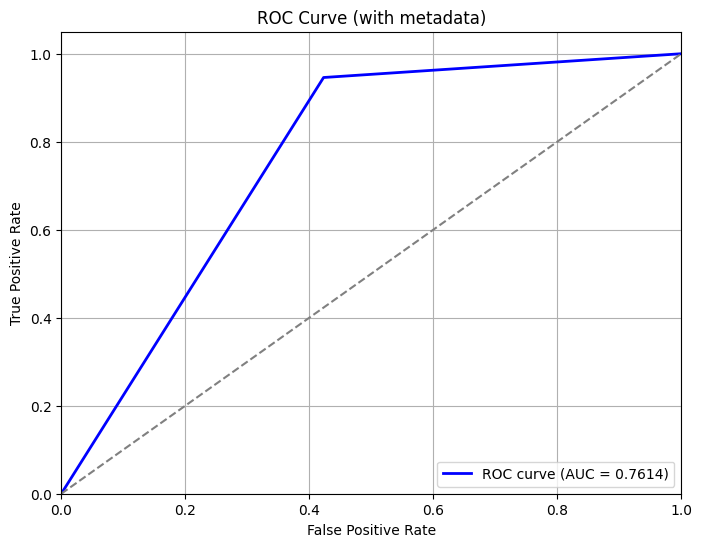

In [94]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_pred)  # Get false positive & true positive rates
roc_auc = auc(fpr, tpr)  # Compute AUC

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Random classifier line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (with metadata)')
plt.legend(loc="lower right")
plt.grid()
plt.show()

### Model building (without including metadata for classification)

In [95]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import roc_auc_score, classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Extract feature_vector and normalize it
x_without = np.array(metadata_final['Concatenated_Features'].tolist())
sc = StandardScaler()
x_without = sc.fit_transform(x_without)  # Normalize feature vectors

# Target variable
y_without = metadata_final[['case_ISUP', 'case_csPCa']].values  
le = LabelEncoder()

# Train-test split
x_train_without, x_test_without, y_train_without, y_test_without = train_test_split(
    x_without, y_without, test_size=0.05, shuffle=True, random_state=42, stratify=y_without)

# Extract ISUP grades & corresponding clinical significance
case_ISUP_without = y_test_without[:, 0]
case_csPCa_without = y_test_without[:, 1]

# Consider only clinical significance for classification
y_train_without = y_train_without[:, 1]
y_test_without = y_test_without[:, 1]

# Perform label encoding of the target variable
y_train_without = le.fit_transform(y_train_without)
y_test_without = le.transform(y_test_without)

# Define the model
without_metadata_model = Sequential([
    Input(shape=(x_without.shape[1],)),  # Dynamically set input shape
    BatchNormalization(),
    
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    
    Dense(1, activation='sigmoid')  # Output layer
])

# Compile the model
without_metadata_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', 'AUC']
)

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
]

# Train the model
history = without_metadata_model.fit(
    x_train_without, y_train_without, validation_split=0.30, epochs=30, batch_size=32, callbacks=callbacks, verbose=1
)

# Evaluating the model on test data
test_loss_without, test_acc_without, test_auc_without = without_metadata_model.evaluate(x_test_without, y_test_without)
print(f'\nTest accuracy: {test_acc_without:.4f} Test AUC: {test_auc_without:.4f}')


Epoch 1/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 10s 151ms/step - AUC: 0.5864 - accuracy: 0.5617 - loss: 0.8661 - val_AUC: 0.7176 - val_accuracy: 0.6453 - val_loss: 0.6983 - learning_rate: 0.0010
Epoch 2/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - AUC: 0.7965 - accuracy: 0.7163 - loss: 0.5714 - val_AUC: 0.7566 - val_accuracy: 0.6704 - val_loss: 0.6177 - learning_rate: 0.0010
Epoch 3/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - AUC: 0.8960 - accuracy: 0.8051 - loss: 0.4021 - val_AUC: 0.7441 - val_accuracy: 0.6397 - val_loss: 0.6923 - learning_rate: 0.0010
Epoch 4/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - AUC: 0.9144 - accuracy: 0.8349 - loss: 0.3744 - val_AUC: 0.7583 - val_accuracy: 0.6927 - val_loss: 0.6979 - learning_rate: 0.0010
Epoch 5/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - AUC: 0.9434 - accuracy: 0.8629 - loss: 0.3041 - val_AUC: 0.7738 - val_accuracy: 0.7067 - val_loss: 0.6764 - learning_rate: 0.0010
Epoch 6/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - AUC: 0.9522 - accuracy: 0.8780 - lo

In [96]:
y_prob_without = without_metadata_model.predict(x_test_without)
y_pred_without = (y_prob_without > 0.5).astype(int)  # Predictions

# Performance evaluation
print("AUC Score: ", round(roc_auc_score(y_test_without, y_prob_without), 3))
print("Classification Report:\n", classification_report(y_test_without, y_pred_without))

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 295ms/step
AUC Score:  0.798
Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.85      0.72        26
           1       0.86      0.65      0.74        37

    accuracy                           0.73        63
   macro avg       0.74      0.75      0.73        63
weighted avg       0.76      0.73      0.73        63



In [97]:
# Creating results DataFrame
results_df_without = pd.DataFrame()
results_df_without['case_ISUP'] = case_ISUP_without
results_df_without['case_csPCa'] = case_csPCa_without
results_df_without['predicted_csPCa'] = y_pred_without

# Efficient vectorized calculations for TP, FN, FP, TN
results_df_without['TP'] = (results_df_without['case_csPCa'] == 1) & (results_df_without['predicted_csPCa'] == 1)
results_df_without['FN'] = (results_df_without['case_csPCa'] == 1) & (results_df_without['predicted_csPCa'] == 0)
results_df_without['FP'] = (results_df_without['case_csPCa'] == 0) & (results_df_without['predicted_csPCa'] == 1)
results_df_without['TN'] = (results_df_without['case_csPCa'] == 0) & (results_df_without['predicted_csPCa'] == 0)

# Convert boolean to integers
results_df_without[['TP', 'FN', 'FP', 'TN']] = results_df_without[['TP', 'FN', 'FP', 'TN']].astype(int)

def calculate_precision_recall(df):
    grades = sorted(df['case_ISUP'].unique())  # Unique ISUP grades
    result_list = []

    for grade in grades:
        grade_df = df[df['case_ISUP'] == grade]  # Filter by grade

        tp = grade_df['TP'].sum()
        fn = grade_df['FN'].sum()
        fp = df[df['case_ISUP'] != grade]['FP'].sum()  # FP should be outside the grade
        tn = grade_df['TN'].sum()

        if grade >= 2:
            # Use original TP-based formula for grades 2 and above
            precision = round(tp / (tp + fp), 2) if (tp + fp) > 0 else 0
            recall = round(tp / (tp + fn), 2) if (tp + fn) > 0 else 0
        else:
            # Use TN-based formula for grades 0 and 1
            precision = round(tn / (tn + fn), 2) if (tn + fn) > 0 else 0
            recall = round(tn / (tn + fp), 2) if (tn + fp) > 0 else 0

        result_list.append((grade, precision, recall))

    return pd.DataFrame(result_list, columns=['Grade', 'Precision', 'Recall'])

# Compute precision and recall
metrics_df_without = calculate_precision_recall(results_df_without)
print(metrics_df_without)

   Grade  Precision  Recall
0      0       1.00    0.93
1      1       1.00    0.75
2      2       0.33    0.20
3      3       0.60    0.67
4      4       0.67    0.89
5      5       0.67    0.89


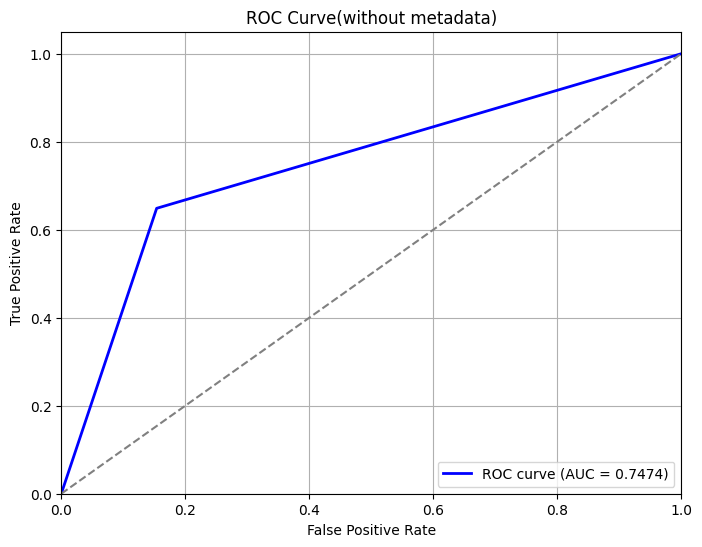

In [98]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

fpr_without, tpr_without, _without = roc_curve(y_test_without, y_pred_without)  # Get false positive & true positive rates
roc_auc_without = auc(fpr_without, tpr_without)  # Compute AUC

plt.figure(figsize=(8, 6))
plt.plot(fpr_without, tpr_without, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc_without:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve(without metadata)')
plt.legend(loc="lower right")
plt.grid()
plt.show()